In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

In [2]:
def SIR(t, y, beta, gamma):
  S = y[0]
  I = y[1]
  R = y[2]
  dSdt = -beta * S * I
  dIdt = beta * S * I - gamma * I
  dRdt = gamma * I
  return np.array([dSdt, dIdt, dRdt])

In [3]:
def rk4(f, y0, t, beta, gamma):
  n = len(t)
  y0 = np.array(y0)
  y = np.zeros((n, len(y0)))
  y[0] = y0

  for i in range(n-1):
    h = t[i+1] - t[i]

    k1 = np.array(f(t[i], y[i], beta, gamma))
    k2 = np.array(f(t[i] + h/2, y[i] + h*k1/2, beta, gamma))
    k3 = np.array(f(t[i] + h/2, y[i] + h*k2/2, beta, gamma))
    k4 = np.array(f(t[i] + h, y[i] + h*k3, beta, gamma))

    y[i+1] = y[i] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

  return y

In [4]:
class sir_nn(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = nn.Sequential(
               nn.Linear(1, 32),
               nn.Tanh(),
               nn.Linear(32, 32),
               nn.Tanh(),
               nn.Linear(32, 32),
               nn.Tanh(),
               nn.Linear(32, 3))

    self.beta = nn.Parameter(torch.tensor([0.5]))
    self.gamma = nn.Parameter(torch.tensor([0.5]))

  def forward(self, t):
    return nn.Softplus()(self.net(t))

In [63]:
# Derivar
def derivar(y, t):
  return torch.autograd.grad(y, t, grad_outputs= torch.ones_like(y), create_graph= True, retain_graph= True)[0]

# Losses
def loss_ic(model, y_0):
  m_0 = model(torch.tensor([0.0]))
  y_0_t = torch.tensor(y_0)

  return torch.mean((m_0[:3] - y_0_t)**2)

def loss_edo(model, t):
  tmp = model(t)
  s = tmp[:, 0:1]
  i = tmp[:, 1:2]
  r = tmp[:, 2:3]
  beta = model.beta
  gamma = model.gamma

  ds_dt = derivar(s, t)
  di_dt = derivar(i, t)
  dr_dt = derivar(r, t)

  diff_s = ds_dt + beta * s * i
  diff_i = di_dt - beta * s * i + gamma * i
  diff_r = dr_dt -  gamma * i

  return torch.mean(diff_s**2 + diff_i**2 + diff_r**2)

def loss_data(model, t, id_h_points, sol):
  t_h = t[id_h_points]

  model_h = model(t_h)
  sol_h = torch.tensor(sol[id_h_points])

  # Tensor's
  return torch.mean((sol_h[:, 1] - model_h[:, 1])**2)

def loss_sum_1(model, t):
  tmp = model(t)

  S = tmp[:, 0:1] 
  I   = tmp[:, 1:2]
  R = tmp[:, 2:3]

  return torch.mean((S + I + R - 1.0)**2)

def loss_r0(model, beta, gamma):
  return ( ((beta/gamma) - (model.beta/model.gamma))**2 )

In [15]:
# Timeline
t_start = 0.0
t_end = 40.0
n_points = 2000
t_real = torch.linspace(t_start, t_end, n_points).reshape(-1, 1)
t_real.requires_grad = True


# Initial conditions
s_0, i_0, r_0 = 0.95, 0.05, 0.0
y_0 = np.array([s_0, i_0, r_0])


# N Epocas
n_ephocs = 10000

# Beta & gamma
beta = 0.8
gamma = 0.05


# Real RK4 Solution
sol = rk4(SIR, y_0, t_real.detach().numpy(), beta, gamma);

# Learning Rate
lr = 1e-3

In [16]:
# Get grads
def get_grad_data(loss, model):
  net_params = list(model.net.parameters())  # ← Solo la red
    
  grads = torch.autograd.grad(loss,
                              net_params,
                              retain_graph=True,
                              create_graph=False)

  t_median = 0.0
  t_max = 0.0

  counter = 0
  
  for grad in grads:
    if (grad is None):
      continue
      
    counter += 1
    t_median += grad.abs().mean().item();
    if (t_max < grad.abs().max().item()):
      t_max = grad.abs().max().item()

  t_median /= counter
  return t_median, t_max

In [21]:
# NN Simulation
def train(hasWeights, nHelperPoints, sol_noisy):
  model = sir_nn()  
  # Optimizer
  optimizer = optim.Adam(model.parameters(), lr)

  # Weights
  ic_weight = 10
  edo_weight = 40
  data_weight = 0.9
  sum_weight = 1


  #Helper points
  h_points = []
  id_h_points = []
  
  id_h_points = np.linspace(0, n_points - 1, nHelperPoints, dtype = int)
  h_points = t_real[id_h_points].detach().numpy()

  # Training loop
  startTime = time.perf_counter()
  for epoch in range(n_ephocs):

    if (hasWeights == True):
      loss = ic_weight * loss_ic(model, y_0) + edo_weight * loss_edo(model, t_real) + data_weight * loss_data(model, t_real, id_h_points, sol_noisy) + sum_weight * loss_sum_1(model, t_real) + 5*loss_r0(model, beta, gamma)
    else:
      loss = loss_ic(model, y_0) + loss_edo(model, t_real) + loss_data(model, t_real, id_h_points, sol_noisy) + loss_sum_1(model, t_real)  
  
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    
  endTime = time.perf_counter()
  return model, endTime - startTime, id_h_points

In [22]:
# Noise
noise_base = []
noise_base.append(np.random.uniform(0.7, 1.0, size=sol.shape[0])) # S
noise_base.append(np.random.uniform(0.7, 1.0, size=sol.shape[0])) # I
noise_base.append(np.random.uniform(0.7, 1.0, size=sol.shape[0])) # R

noise_sign = []
noise_sign.append(np.random.choice([-1, 1], size=sol.shape[0])) # S
noise_sign.append(np.random.choice([-1, 1], size=sol.shape[0])) # I
noise_sign.append(np.random.choice([-1, 1], size=sol.shape[0])) # R

In [42]:
def getNoisySolution(solution, noiseBase, noiseSign, percentage):
  solNoisy = solution.copy()
  for k in range(3):  # S, I, R
    maxVal = np.max(solution[:, k])
    noiseScaled = noiseBase[k] * noiseSign[k] * (percentage/100.0) * maxVal
    
    solNoisy[:, k] += noiseScaled
    solNoisy[:, k]  = np.abs(sol_noisy[:, k])
  solNoisy = np.clip(solNoisy, 0.0, 1.0)

  return solNoisy

## Unbalanced vs Balanced model, using n = 10%

In [ ]:
solNoisy = getNoisySolution(sol, noise_base, noise_sign, 10.0)
print("Start")
modelBalanced, trainingTime, idHPoints = train(hasWeights = True, nHelperPoints = 10, sol_noisy = solNoisy)
modelUnbalanced, trainingTime, idHPoints = train(hasWeights = True, nHelperPoints = 10, sol_noisy = solNoisy)
print("Done")

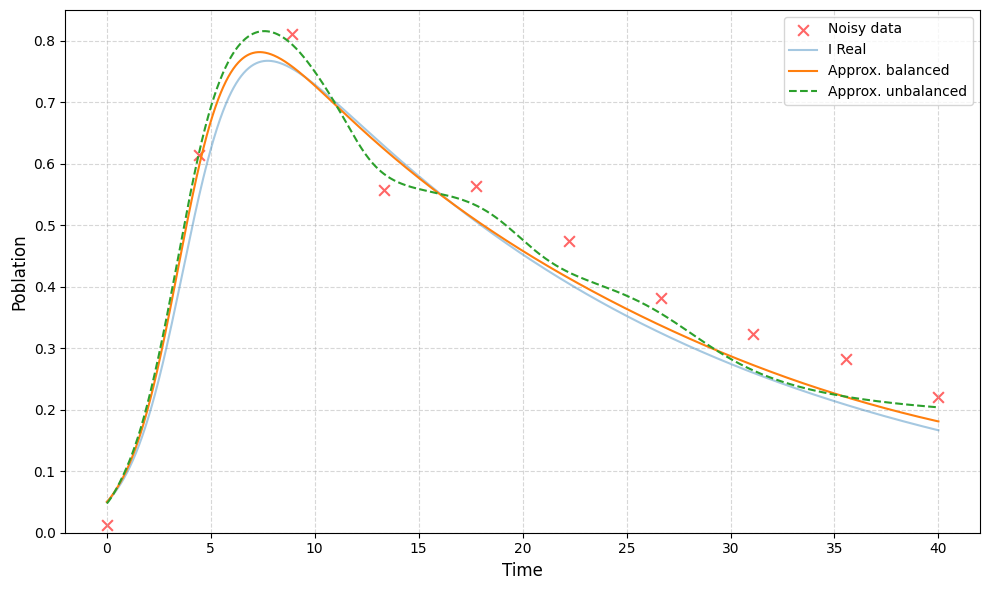

In [39]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
red = "#ff0000"

plt.figure(figsize=(10, 6))

h_points = t_real[idHPoints].detach().numpy()
plt.scatter(h_points, sol_noisy[idHPoints, 1], color = red, marker='x', s=60, label="Noisy data", alpha=0.6)

# REAL
t_plot = t_real.detach().numpy()
plt.plot(t_plot, sol[:, 1], color=colors[0], linestyle='-', linewidth=1.5, alpha=0.4, label=f"I Real")


# PINNs
model_balanced = modelBalanced(t_real).detach().numpy()
model_unbalanced = modelUnbalanced(t_real).detach().numpy()

plt.plot(t_plot, model_balanced[:, 1], color=colors[1], linestyle='-', linewidth=1.5, label=f"Approx. balanced")
plt.plot(t_plot, model_unbalanced[:, 1], color=colors[2], linestyle='--', linewidth=1.5, label=f"Approx. unbalanced")


plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Poblation', fontsize=12)
plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.ylim(0.0, 0.85)

plt.show()

## Comparing different n(noise)

In [43]:
noiseLevels = [2.5, 5.0, 7.5, 10.0]
dictionary = []

print("Start")
for noise in noiseLevels:
  print(f"Training with noise {noise}")
  solNoisy = getNoisySolution(sol, noise_base, noise_sign, noise)
  model, trainingTime, idHPoints = train(hasWeights = True, nHelperPoints = 16, sol_noisy = solNoisy)

  dictionary.append({"noise": noise, "model": model})
print("End")

Start
Training with noise 2.5
Training with noise 5.0
Training with noise 7.5
Training with noise 10.0
End


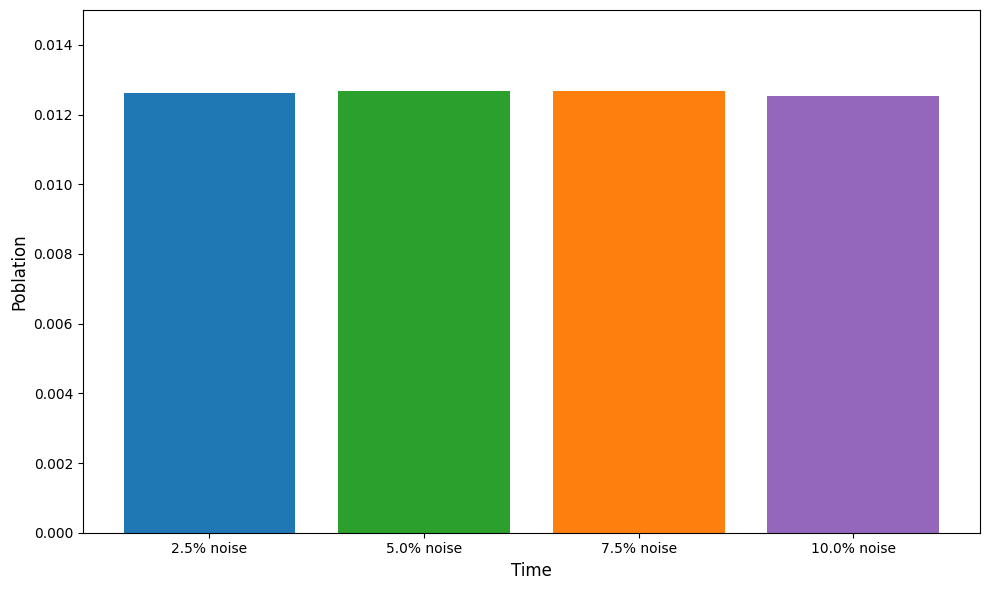

In [62]:
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']
red = "#ff0000"

plt.figure(figsize=(10, 6))

h_points = t_real[idHPoints].detach().numpy()
#plt.scatter(h_points, sol_noisy[idHPoints, 1], color = red, marker = 'x', s = 60, label = "Noisy data", alpha = 0.6)

# REAL
t_plot = t_real.detach().numpy()
#plt.plot(t_plot, sol[:, 1], color = colors[0], linestyle = '-', linewidth = 1.5, alpha = 0.4, label = f"{labels[1]} Real")


# PINNs


errors = []
noisePlot = []
for i in range(4):
  curDict = dictionary[i]
  modelToPlot = curDict["model"](t_real).detach().numpy()
  error = np.sqrt(np.mean((modelToPlot[:, 1] - sol[:, 1])**2))
  noisePlot.append(f"{curDict["noise"]}% noise")
  errors.append(error)

plt.bar(noisePlot, errors, color = colors)
plt.xlabel('Time', fontsize = 12)
plt.ylabel('Poblation', fontsize = 12)
plt.tight_layout()
plt.ylim(0.0, 0.015)

plt.show()

## Experimenting with partial data

In [64]:
print("Start")
solNoisy = getNoisySolution(sol, noise_base, noise_sign, noise)
model, trainingTime, idHPoints = train(hasWeights = True, nHelperPoints = 16, sol_noisy = solNoisy)
print("End")

Start
End


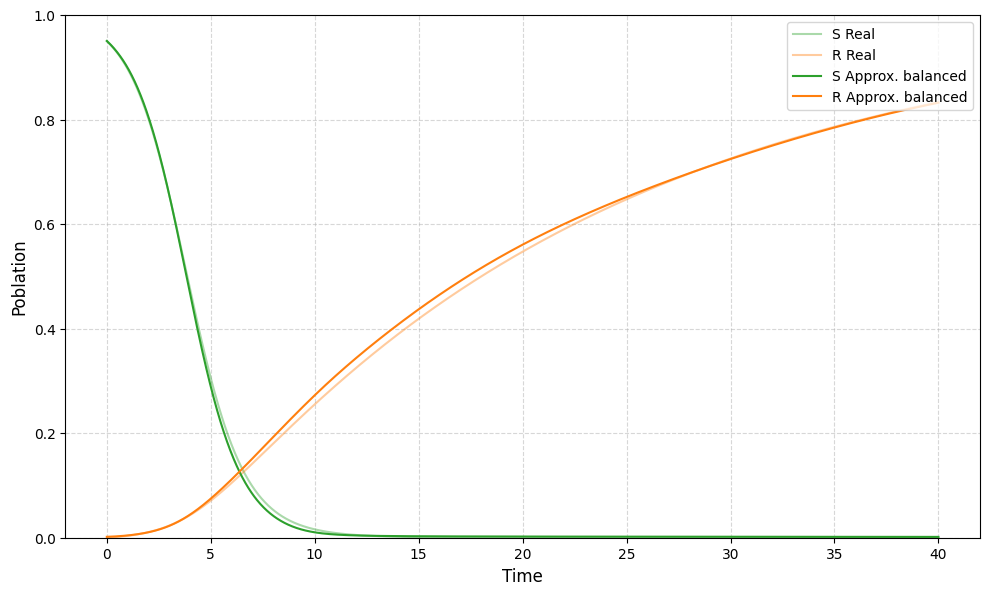

In [68]:
red = "#ff0000"

plt.figure(figsize=(10, 6))

h_points = t_real[idHPoints].detach().numpy()
#plt.scatter(h_points, sol_noisy[idHPoints, 1], color = red, marker='x', s=60, label="Noisy data", alpha=0.6)

# REAL
t_plot = t_real.detach().numpy()
plt.plot(t_plot, sol[:, 0], color=colors[1], linestyle='-', linewidth=1.5, alpha=0.4, label=f"S Real")
plt.plot(t_plot, sol[:, 2], color=colors[2], linestyle='-', linewidth=1.5, alpha=0.4, label=f"R Real")


# PINNs
modelToPlot = model(t_real).detach().numpy()

plt.plot(t_plot, modelToPlot[:, 0], color=colors[1], linestyle='-', linewidth=1.5, label=f"S Approx. balanced")
plt.plot(t_plot, modelToPlot[:, 2], color=colors[2], linestyle='-', linewidth=1.5, label=f"R Approx. balanced")


plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Poblation', fontsize=12)
plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.ylim(0.0, 1.0)

plt.show()

## RMSE comparing different training points aswell as different noise levels

In [10]:
noise = [0.0, 2.5, 5.0, 7.5, 10.0]
nPoints = [2, 4, 8, 16, 32]
dictionary = {}

print("Start")
for noiseLevel in noise:
  print(f"start with noise {noiseLevel}")
  # Noise
  sol_noisy = getNoisySolution(sol, noise_base, noise_sign, noiseLevel)

  for point in nPoints:
    print(f"\tnPoints: {point}")
    # Balanced
    model, trainingTime = train(hasWeights = True, nHelperPoints = point, sol_noisy = sol_noisy)
    errorI = model(t_real).detach().numpy()[:, 1] - sol[:, 1]
    dictionary[f"balanced_{noiseLevel}_{point}"] = {"Type": "Balanced", "n" : point, "noise": noiseLevel, "RMSE" : (np.sqrt(np.mean(errorI**2))), "model": model, "Time": trainingTime}
    print("\t\tBalanced")
    
    # Unbalanced
    model, trainingTime = train(hasWeights = False, nHelperPoints = point, sol_noisy = sol_noisy)
    errorI = model(t_real).detach().numpy()[:, 1] - sol[:, 1]
    dictionary[f"unbalanced_{noiseLevel}_{point}"] = {"Type": "Unbalanced", "n" : point, "noise": noiseLevel, "RMSE" : (np.sqrt(np.mean(errorI**2))), "model": model, "Time": trainingTime}
    print("\t\tUnbalanced")

print("End")

Start
start with noise 0.0
	nPoints: 2
		Balanced
		Unbalanced
	nPoints: 4
		Balanced
		Unbalanced
	nPoints: 8
		Balanced
		Unbalanced
	nPoints: 16
		Balanced
		Unbalanced
	nPoints: 32
		Balanced
		Unbalanced
start with noise 2.5
	nPoints: 2
		Balanced
		Unbalanced
	nPoints: 4
		Balanced
		Unbalanced
	nPoints: 8
		Balanced
		Unbalanced
	nPoints: 16
		Balanced
		Unbalanced
	nPoints: 32
		Balanced
		Unbalanced
start with noise 5.0
	nPoints: 2
		Balanced
		Unbalanced
	nPoints: 4
		Balanced
		Unbalanced
	nPoints: 8
		Balanced
		Unbalanced
	nPoints: 16
		Balanced
		Unbalanced
	nPoints: 32
		Balanced
		Unbalanced
start with noise 7.5
	nPoints: 2
		Balanced
		Unbalanced
	nPoints: 4
		Balanced
		Unbalanced
	nPoints: 8
		Balanced
		Unbalanced
	nPoints: 16
		Balanced
		Unbalanced
	nPoints: 32
		Balanced
		Unbalanced
start with noise 10.0
	nPoints: 2
		Balanced
		Unbalanced
	nPoints: 4
		Balanced
		Unbalanced
	nPoints: 8
		Balanced
		Unbalanced
	nPoints: 16
		Balanced
		Unbalanced
	nPoints: 32
		

In [13]:
unbalanced = []
balanced = []

for key in dictionary:
  elem = dictionary[key]
  if (elem["Type"] == "Unbalanced"):
    unbalanced.append(elem)
  else:
    balanced.append(elem)

for elem in balanced:
  print(f"{elem["Type"]}\t-\tn:{elem["n"]}\t-\tnoise:{elem["noise"]}\t-\tRMSE:{elem["RMSE"]:.4f}\t-\talpha:{elem["model"].gamma.item():.4f}\t-\tbeta:{elem["model"].beta.item():.4f}")

print("\n\n====================================\n\n")
for elem in unbalanced:
  print(f"{elem["Type"]}\t-\tn:{elem["n"]}\t-\tnoise:{elem["noise"]}\t-\tRMSE:{elem["RMSE"]:.4f}\t-\talpha:{elem["model"].gamma.item():.4f}\t-\tbeta:{elem["model"].beta.item():.4f}")

Balanced	-	n:2	-	noise:0.0	-	RMSE:0.1718	-	alpha:0.0608	-	beta:0.3887
Balanced	-	n:4	-	noise:0.0	-	RMSE:0.0096	-	alpha:0.0509	-	beta:0.7662
Balanced	-	n:8	-	noise:0.0	-	RMSE:0.0004	-	alpha:0.0502	-	beta:0.8005
Balanced	-	n:16	-	noise:0.0	-	RMSE:0.0009	-	alpha:0.0503	-	beta:0.7998
Balanced	-	n:32	-	noise:0.0	-	RMSE:0.0007	-	alpha:0.0503	-	beta:0.7999
Balanced	-	n:2	-	noise:2.5	-	RMSE:0.1869	-	alpha:0.0631	-	beta:0.3654
Balanced	-	n:4	-	noise:2.5	-	RMSE:0.0611	-	alpha:0.0558	-	beta:0.6178
Balanced	-	n:8	-	noise:2.5	-	RMSE:0.0038	-	alpha:0.0496	-	beta:0.8004
Balanced	-	n:16	-	noise:2.5	-	RMSE:0.0062	-	alpha:0.0503	-	beta:0.8189
Balanced	-	n:32	-	noise:2.5	-	RMSE:0.0023	-	alpha:0.0503	-	beta:0.7937
Balanced	-	n:2	-	noise:5.0	-	RMSE:0.2025	-	alpha:0.0662	-	beta:0.3435
Balanced	-	n:4	-	noise:5.0	-	RMSE:0.0965	-	alpha:0.0605	-	beta:0.5389
Balanced	-	n:8	-	noise:5.0	-	RMSE:0.0080	-	alpha:0.0490	-	beta:0.8004
Balanced	-	n:16	-	noise:5.0	-	RMSE:0.0124	-	alpha:0.0504	-	beta:0.8401
Balanced	-	n:32